<a href="https://colab.research.google.com/github/Pranesh-M-2006/Mechine-learning/blob/main/Exp%204/Scenario_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


In [4]:
df = pd.read_csv("spam.csv", encoding='latin-1')[['v1','v2']]
df.columns = ['label', 'message']

df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", "", text)
    text = re.sub(r'\d+', '', text)
    return text

df['message'] = df['message'].apply(clean_text)


In [6]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['message'])


In [7]:
encoder = LabelEncoder()
y = encoder.fit_transform(df['label'])  # ham=0, spam=1


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [9]:
model = MultinomialNB(alpha=1.0)   # Laplace smoothing (alpha=1)
model.fit(X_train, y_train)


MultinomialNB()

In [10]:
y_pred = model.predict(X_test)


In [11]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


Accuracy : 0.9704035874439462
Precision: 0.8774193548387097
Recall   : 0.9066666666666666
F1 Score : 0.8918032786885246


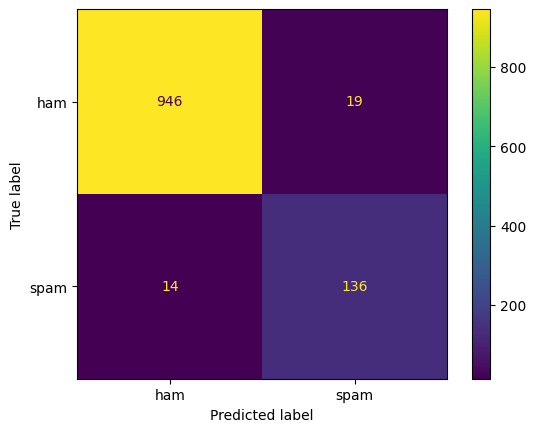

In [12]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot()
plt.show()


In [13]:
misclassified = X_test[y_test != y_pred]

indices = np.where(y_test != y_pred)[0]

for i in indices[:5]:
    print("Actual:", encoder.inverse_transform([y_test[i]])[0])
    print("Predicted:", encoder.inverse_transform([y_pred[i]])[0])
    print("Message:", df.iloc[i]['message'])
    print("-----")


Actual: ham
Predicted: spam
Message: go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat
-----
Actual: ham
Predicted: spam
Message: iû÷m going to try for  months ha ha only joking
-----
Actual: spam
Predicted: ham
Message: k tell me anything about you
-----
Actual: ham
Predicted: spam
Message: tell where you reached
-----
Actual: ham
Predicted: spam
Message: for real when u getting on yo i only need  more tickets and one more jacket and im done i already used all my multis
-----


In [14]:
model2 = MultinomialNB(alpha=0.1)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

print("Accuracy with alpha=0.1:", accuracy_score(y_test, y_pred2))


Accuracy with alpha=0.1: 0.9721973094170404


In [15]:
feature_names = vectorizer.get_feature_names_out()
spam_probs = model.feature_log_prob_[1]

top_spam_indices = np.argsort(spam_probs)[-10:]

for i in top_spam_indices:
    print(feature_names[i])


is
now
or
the
for
free
your
you
call
to


In [16]:
spam_words = df[df['label']=='spam']['message']
ham_words = df[df['label']=='ham']['message']

spam_vec = CountVectorizer().fit_transform(spam_words)
ham_vec = CountVectorizer().fit_transform(ham_words)

print("Total Spam Words:", spam_vec.sum())
print("Total Ham Words:", ham_vec.sum())


Total Spam Words: 14957
Total Ham Words: 61496
